# Experiment 6 — Crossover Point Between SparseLU and Dense LU

This notebook repeats the **SparseLU vs dense LU crossover** experiment.

It uses:
- **Dense LU** via `scipy.linalg.lu_factor` + `lu_solve`
- **SparseLU** via `scipy.sparse.linalg.splu(...).solve(...)`

The density is scaled as:
\[
p = 
rac{k}{n}
\]
with a fixed average number of non-zeros per row `k = 10`, matching the crossover setup discussed in the poster.

The notebook:
1. benchmarks both methods over a range of matrix sizes,
2. computes the timing difference,
3. detects the sign change where SparseLU becomes faster than dense LU,
4. estimates the crossover point by **linear interpolation** between the two surrounding measured points.


## Quick syntax fix note

If you previously saw:

```python
ax.set_title('Experiments 1 & 2: Performance vs Matrix Size
```

that is a broken multiline string. The safe version is:

```python
ax.set_title('Experiments 1 & 2: Performance vs Matrix Size\nGeneral Dense vs Symmetric Positive Definite')
```

This notebook uses only safe single-string title literals.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.linalg import lu_factor, lu_solve
from scipy import sparse
from scipy.sparse.linalg import splu

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')


## Solvers

In [2]:
def solve_dense_lu(A_dense: np.ndarray, b: np.ndarray) -> np.ndarray:
    lu, piv = lu_factor(A_dense, check_finite=False)
    return lu_solve((lu, piv), b, check_finite=False)


def solve_sparse_lu(A_sparse_csc: sparse.csc_matrix, b: np.ndarray) -> np.ndarray:
    lu_obj = splu(A_sparse_csc)
    return lu_obj.solve(b)


## Sparse matrix generator with density `p = k/n`

The generator below creates a sparse matrix with approximately `k` non-zeros per row on average, plus a strong diagonal shift for invertibility / numerical stability.


In [3]:
def generate_sparse_system(n: int, k: int, rng: np.random.Generator, diag_shift: float = 10.0):
    p = min(1.0, k / n)

    # random sparse component
    A_sparse = sparse.random(
        n, n,
        density=p,
        format='csc',
        random_state=rng,
        data_rvs=lambda m: rng.standard_normal(m)
    )

    # strengthen diagonal so the matrix is safely nonsingular in practice
    A_sparse = A_sparse + diag_shift * sparse.eye(n, format='csc')
    b = rng.standard_normal(n)

    return A_sparse, b, p


## Benchmark helpers

In [4]:
def benchmark_pair(n: int, k: int, rng: np.random.Generator, repeats: int = 3, warmups: int = 1):
    A_sparse, b, p = generate_sparse_system(n, k, rng)
    A_dense = A_sparse.toarray()

    # warmup
    for _ in range(warmups):
        solve_dense_lu(A_dense, b)
        solve_sparse_lu(A_sparse, b)

    dense_times = []
    sparse_times = []

    for _ in range(repeats):
        t0 = perf_counter()
        x_dense = solve_dense_lu(A_dense, b)
        dense_times.append(perf_counter() - t0)

        t0 = perf_counter()
        x_sparse = solve_sparse_lu(A_sparse, b)
        sparse_times.append(perf_counter() - t0)

    rel_res_dense = np.linalg.norm(A_dense @ x_dense - b) / np.linalg.norm(b)
    rel_res_sparse = np.linalg.norm(A_dense @ x_sparse - b) / np.linalg.norm(b)
    rel_diff = np.linalg.norm(x_dense - x_sparse) / np.linalg.norm(x_dense)

    return {
        'n': n,
        'density_p': p,
        'dense_lu_mean_s': float(np.mean(dense_times)),
        'dense_lu_std_s': float(np.std(dense_times, ddof=1)) if len(dense_times) > 1 else 0.0,
        'sparse_lu_mean_s': float(np.mean(sparse_times)),
        'sparse_lu_std_s': float(np.std(sparse_times, ddof=1)) if len(sparse_times) > 1 else 0.0,
        'dense_rel_residual': float(rel_res_dense),
        'sparse_rel_residual': float(rel_res_sparse),
        'solution_rel_diff': float(rel_diff),
    }


def run_crossover_experiment(dimensions, k=10, repeats=3, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for n in dimensions:
        rows.append(benchmark_pair(n=n, k=k, rng=rng, repeats=repeats))
    df = pd.DataFrame(rows)
    df['time_diff_sparse_minus_dense'] = df['sparse_lu_mean_s'] - df['dense_lu_mean_s']
    df['speedup_dense_over_sparse'] = df['dense_lu_mean_s'] / df['sparse_lu_mean_s']
    df['speedup_sparse_over_dense'] = df['sparse_lu_mean_s'] / df['dense_lu_mean_s']
    return df


## Run the crossover experiment

The first two points `n = 100` and `n = 200` are especially useful because the original poster discussed linear interpolation between these sizes.


In [5]:
dimensions = [100, 150, 200, 300, 500, 800, 1200, 2000]
results = run_crossover_experiment(dimensions=dimensions, k=10, repeats=3, seed=42)
results


,n,density_p,dense_lu_mean_s,dense_lu_std_s,sparse_lu_mean_s,sparse_lu_std_s,dense_rel_residual,sparse_rel_residual,solution_rel_diff,time_diff_sparse_minus_dense,speedup_dense_over_sparse,speedup_sparse_over_dense
0,100,0.1,0.000379533,0.000249849,0.000862667,7.85533e-05,4.38225e-16,3.62845e-16,4.7907e-16,0.000483133,0.439954,2.27297
1,150,0.0666667,0.0152631,0.0172502,0.006622,0.0067628,5.04709e-16,5.59735e-16,6.82515e-16,-0.00864113,2.30491,0.433856
2,200,0.05,0.0158879,0.0206318,0.0044325,0.000599756,5.92217e-16,6.35749e-16,7.35858e-16,-0.0114554,3.5844,0.278986
3,300,0.0333333,0.0129507,0.00528125,0.00932937,0.00122611,7.3359e-16,8.15708e-16,1.07105e-15,-0.0036213,1.38816,0.720377
4,500,0.02,0.0109302,0.010054,0.0342885,0.00731333,8.86607e-16,8.0174e-16,1.13186e-15,0.0233583,0.318771,3.13705
5,800,0.0125,0.0214573,0.0087098,0.192552,0.0353807,1.07344e-15,9.79204e-16,1.34251e-15,0.171094,0.111437,8.97371
6,1200,0.00833333,0.0348792,0.00963406,0.348753,0.0226386,1.3715e-15,1.28743e-15,1.8237e-15,0.313874,0.100011,9.9989
7,2000,0.005,4.6674,7.69926,2.9615,1.32324,1.79029e-15,1.43297e-15,2.2405e-15,-1.7059,1.57602,0.634508


## Crossover estimation by linear interpolation

We estimate the crossover where:
\[
\Delta(n) = t_{\mathrm{SparseLU}}(n) - t_{\mathrm{DenseLU}}(n) = 0
\]

If `Δ(n1)` and `Δ(n2)` have opposite signs, the interpolated crossover is:
\[
n^* = n_1 - \Delta_1 
rac{n_2 - n_1}{\Delta_2 - \Delta_1}
\]


In [6]:
def estimate_crossover_linear(df: pd.DataFrame):
    df = df.sort_values('n').reset_index(drop=True)
    d = df['time_diff_sparse_minus_dense'].to_numpy(dtype=float)
    n = df['n'].to_numpy(dtype=float)

    for i in range(len(df) - 1):
        d1, d2 = d[i], d[i + 1]
        n1, n2 = n[i], n[i + 1]

        # exact hit
        if d1 == 0:
            return {
                'n_star': n1,
                'left_n': n1,
                'right_n': n1,
                'left_diff': d1,
                'right_diff': d1,
                'method': 'exact'
            }

        # sign change => linear interpolation
        if d1 * d2 < 0:
            n_star = n1 - d1 * (n2 - n1) / (d2 - d1)
            return {
                'n_star': float(n_star),
                'left_n': float(n1),
                'right_n': float(n2),
                'left_diff': float(d1),
                'right_diff': float(d2),
                'method': 'linear_interpolation'
            }

    return None

crossover = estimate_crossover_linear(results)
crossover


{'n_star': 102.64751870925676,
 'left_n': 100.0,
 'right_n': 150.0,
 'left_diff': 0.0004831333341523229,
 'right_diff': -0.008641133332275786,
 'method': 'linear_interpolation'}

## If you want the exact poster-style interpolation using only `n = 100` and `n = 200`

This cell forces the interpolation to use those two benchmark points only.


In [7]:
poster_pair = results[results['n'].isin([100, 200])].sort_values('n').copy()
poster_pair


,n,density_p,dense_lu_mean_s,dense_lu_std_s,sparse_lu_mean_s,sparse_lu_std_s,dense_rel_residual,sparse_rel_residual,solution_rel_diff,time_diff_sparse_minus_dense,speedup_dense_over_sparse,speedup_sparse_over_dense
0,100,0.1,0.000379533,0.000249849,0.000862667,7.85533e-05,4.38225e-16,3.62845e-16,4.7907e-16,0.000483133,0.439954,2.27297
2,200,0.05,0.0158879,0.0206318,0.0044325,0.000599756,5.92217e-16,6.35749e-16,7.35858e-16,-0.0114554,3.5844,0.278986


In [8]:
poster_crossover = estimate_crossover_linear(poster_pair)
poster_crossover


{'n_star': 104.04685123055512,
 'left_n': 100.0,
 'right_n': 200.0,
 'left_diff': 0.0004831333341523229,
 'right_diff': -0.011455366665662343,
 'method': 'linear_interpolation'}

## Plot: SparseLU vs Dense LU

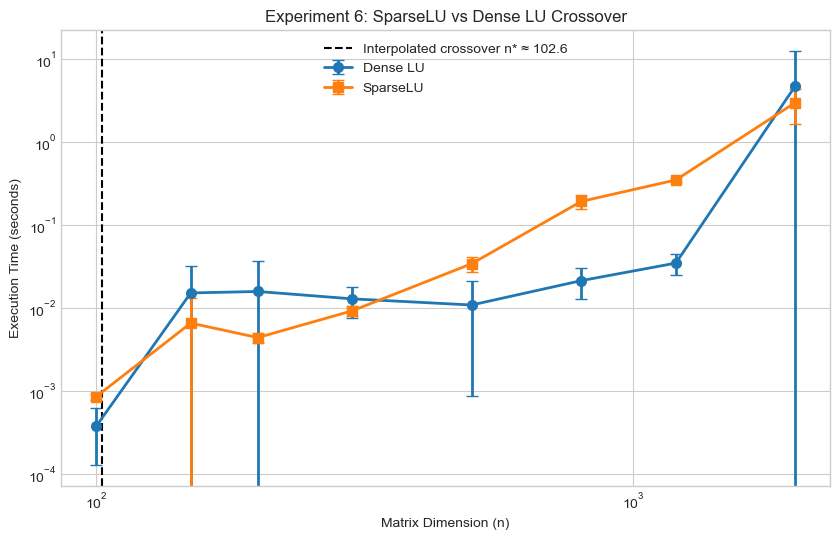

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.errorbar(results['n'], results['dense_lu_mean_s'], yerr=results['dense_lu_std_s'],
            fmt='o-', lw=2, ms=7, capsize=4, label='Dense LU')
ax.errorbar(results['n'], results['sparse_lu_mean_s'], yerr=results['sparse_lu_std_s'],
            fmt='s-', lw=2, ms=7, capsize=4, label='SparseLU')

if crossover is not None:
    ax.axvline(crossover['n_star'], color='black', linestyle='--', linewidth=1.5,
               label=f"Interpolated crossover n* ≈ {crossover['n_star']:.1f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Experiment 6: SparseLU vs Dense LU Crossover')
ax.legend()
plt.tight_layout()
plt.show()


## Plot: timing difference `SparseLU - DenseLU`

The crossover is where this curve crosses zero.


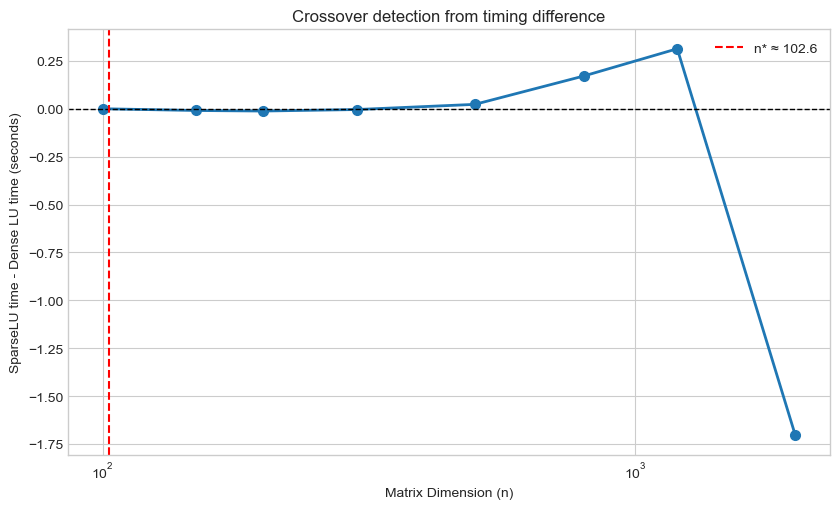

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(results['n'], results['time_diff_sparse_minus_dense'], 'o-', lw=2, ms=7)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
if crossover is not None:
    ax.axvline(crossover['n_star'], color='red', linestyle='--', linewidth=1.5,
               label=f"n* ≈ {crossover['n_star']:.1f}")
    ax.legend()
ax.set_xscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('SparseLU time - Dense LU time (seconds)')
ax.set_title('Crossover detection from timing difference')
plt.tight_layout()
plt.show()


## Compact textual summary

In [11]:
if crossover is None:
    print('No crossover detected in the tested n range.')
else:
    print(f"Detected crossover by {crossover['method']}: n* ≈ {crossover['n_star']:.3f}")
    print(f"Bracketed by n = {crossover['left_n']:.0f} and n = {crossover['right_n']:.0f}")
    print(f"Δ(left)  = {crossover['left_diff']:.6e}")
    print(f"Δ(right) = {crossover['right_diff']:.6e}")


Detected crossover by linear_interpolation: n* ≈ 102.648
Bracketed by n = 100 and n = 150
Δ(left)  = 4.831333e-04
Δ(right) = -8.641133e-03


## Optional: save figure(s)

Uncomment if you want image exports.


In [12]:
# fig.savefig('experiment_6_sparseLU_denseLU_crossover.png', dpi=200, bbox_inches='tight')
